Lendo /eos/user/t/tdeandra/skim_outputs/BPH_Gen_NoFilter.root...
Aplicando Truth Matching...
Filtrando e achatando variáveis (Flat Ntuple)...
Eventos com ao menos um candidato válido: 16188 / 3300108
Total de candidatos perfeitamente pareados (truth matched): 16188
Salvando TTree plana em: Filtered_RECO_Kinematics_NoFSR.root...
Arquivo ROOT salvo com sucesso!
Gerando os plots...


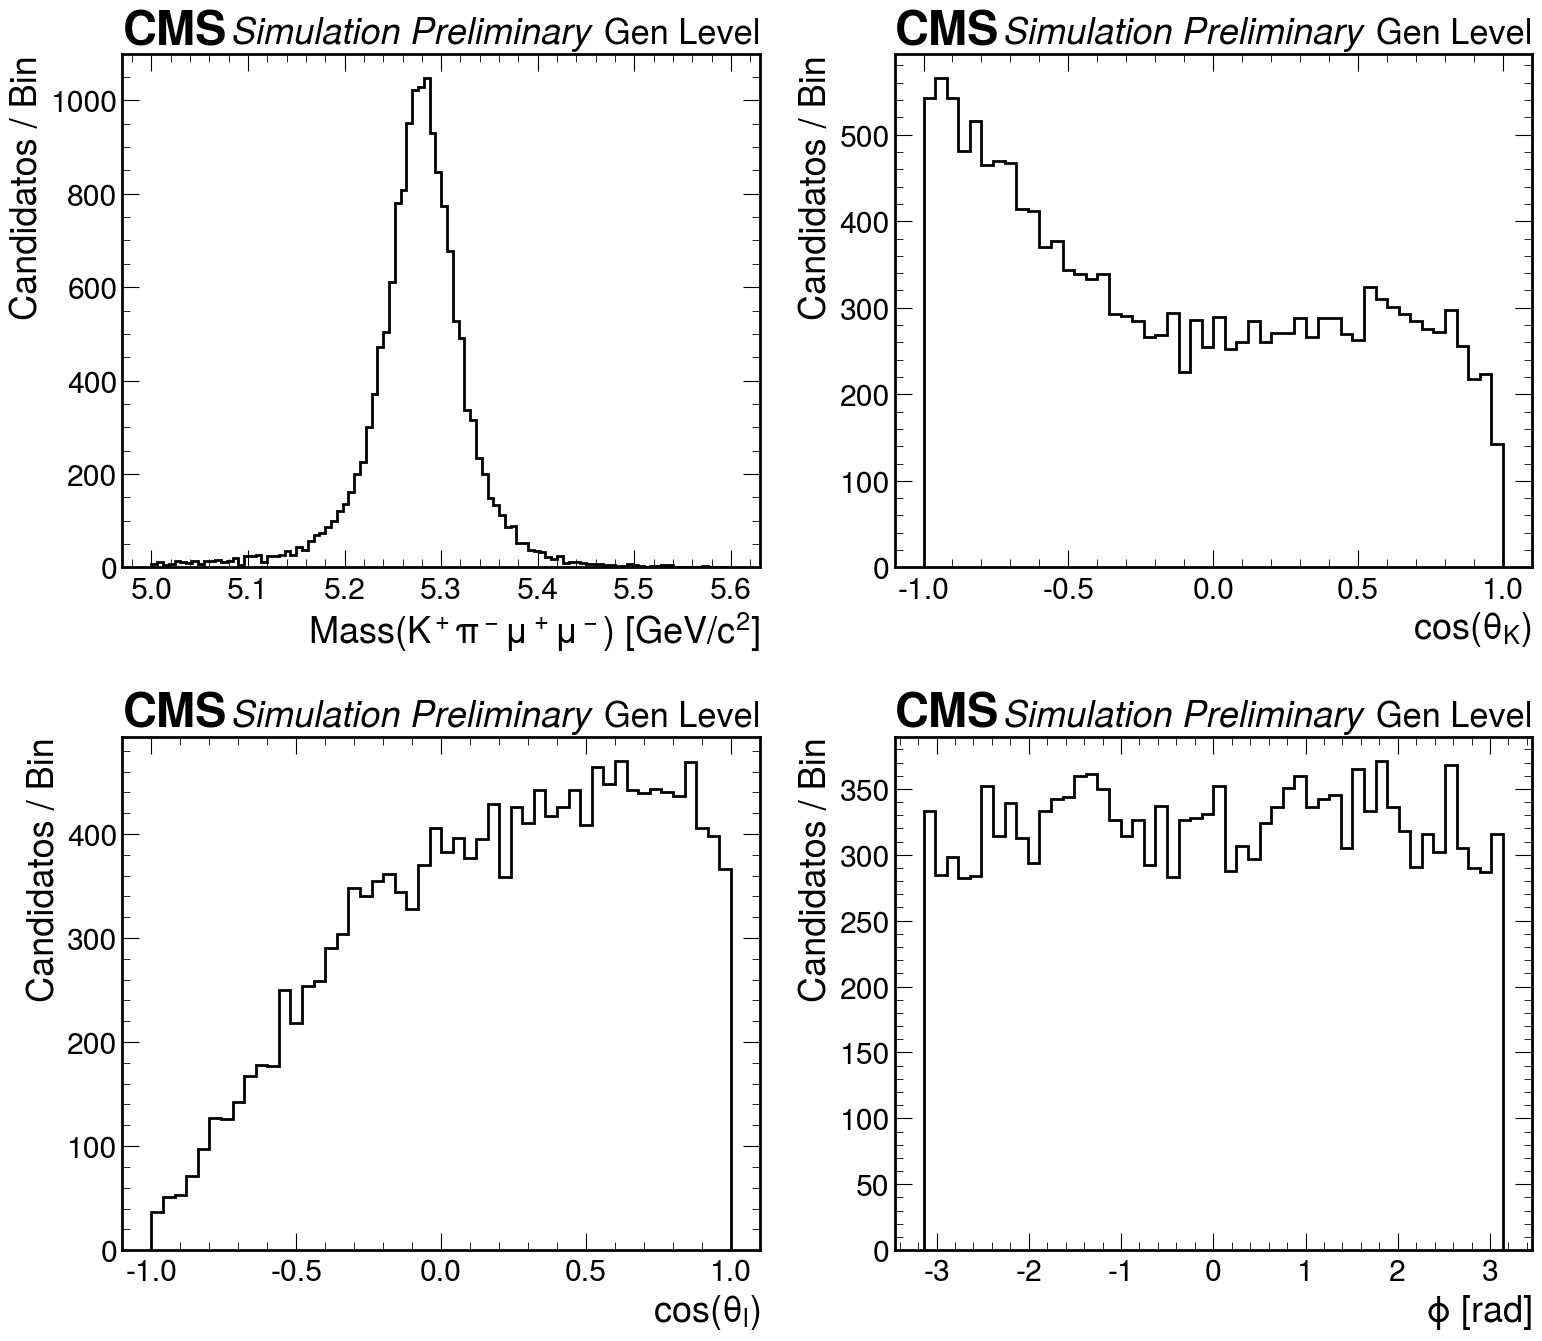

Plots salvos com sucesso como 'BToTrkTrkMuMu_kinematics_truth_matched.png'


In [7]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

# Configurando o estilo do mplhep (Padrão CMS)
hep.style.use(hep.style.CMS)

def apply_strict_truth_match(df):
    # --- 1. Constantes PDG ---
    PDG_B0        = 511
    PDG_KSTAR     = 313
    PDG_KAON_plus = 321
    PDG_PION_neg  = -211
    PDG_MUON_plus = -13
    PDG_MUON_neg  = 13
    PDG_PHOTON    = 22

    mu1_idx  = df["BPHMuon_genPartIdx"][df["BToTrkTrkMuMu_l1_idx"]]
    mu2_idx  = df["BPHMuon_genPartIdx"][df["BToTrkTrkMuMu_l2_idx"]]
    trk1_idx = df["Track_genPartIdx"][df["BToTrkTrkMuMu_trk1_idx"]]
    trk2_idx = df["Track_genPartIdx"][df["BToTrkTrkMuMu_trk2_idx"]]

    # Verificação de Identidade (PDG ID)
    mu1_pdg  = df["BPHGenPart_pdgId"][ak.mask(mu1_idx, mu1_idx >= 0)]
    mu2_pdg  = df["BPHGenPart_pdgId"][ak.mask(mu2_idx, mu2_idx >= 0)]
    trk1_pdg = df["BPHGenPart_pdgId"][ak.mask(trk1_idx, trk1_idx >= 0)]
    trk2_pdg = df["BPHGenPart_pdgId"][ak.mask(trk2_idx, trk2_idx >= 0)]

    flavor_match = (trk1_pdg == PDG_KAON_plus) & (trk2_pdg == PDG_PION_neg) & \
                   (mu1_pdg == PDG_MUON_plus) & (mu2_pdg == PDG_MUON_neg)

    # Linhagem do Hadron (K, Pi -> K* -> B0)
    mom_trk1_idx = df["BPHGenPart_genPartIdxMother"][ak.mask(trk1_idx, trk1_idx >= 0)]
    mom_trk2_idx = df["BPHGenPart_genPartIdxMother"][ak.mask(trk2_idx, trk2_idx >= 0)]
    
    mom_trk1_pdg = df["BPHGenPart_pdgId"][ak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    mom_trk2_pdg = df["BPHGenPart_pdgId"][ak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]
    
    # K e Pi devem vir do mesmo objeto K*0
    match_kstar = (mom_trk1_idx == mom_trk2_idx) & (mom_trk1_idx >= 0) & \
                  (mom_trk1_pdg == PDG_KSTAR) & (mom_trk2_pdg == PDG_KSTAR)
    
    # O K*0 deve vir de um B0
    gmom_trk1_idx = df["BPHGenPart_genPartIdxMother"][ak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    gmom_trk2_idx = df["BPHGenPart_genPartIdxMother"][ak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]
    
    gmom_trk1_pdg = df["BPHGenPart_pdgId"][ak.mask(gmom_trk1_idx, gmom_trk1_idx >= 0)]
    gmom_trk2_pdg = df["BPHGenPart_pdgId"][ak.mask(gmom_trk2_idx, gmom_trk2_idx >= 0)]
    
    match_kstar_to_b0 = (gmom_trk1_idx == gmom_trk2_idx) & (gmom_trk1_idx >= 0) & \
                        (gmom_trk1_pdg == PDG_B0) & (gmom_trk2_pdg == PDG_B0)

    mom_mu1_idx = df["BPHGenPart_genPartIdxMother"][ak.mask(mu1_idx, mu1_idx >= 0)]
    mom_mu2_idx = df["BPHGenPart_genPartIdxMother"][ak.mask(mu2_idx, mu2_idx >= 0)]
    mom_mu1_pdg = df["BPHGenPart_pdgId"][ak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    mom_mu2_pdg = df["BPHGenPart_pdgId"][ak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]
    
    gmom_mu1_idx = df["BPHGenPart_genPartIdxMother"][ak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    gmom_mu2_idx = df["BPHGenPart_genPartIdxMother"][ak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]

    # Muon 1 e 2: Mae e o B0 do hadron OU (Mae e foton e Avo e o B0 do hadron)
    mu1_from_same_b0 = (mom_mu1_idx == gmom_trk1_idx) | \
                       ((mom_mu1_pdg == PDG_PHOTON) & (gmom_mu1_idx == gmom_trk1_idx))

    mu2_from_same_b0 = (mom_mu2_idx == gmom_trk1_idx) | \
                       ((mom_mu2_pdg == PDG_PHOTON) & (gmom_mu2_idx == gmom_trk1_idx))

    # --- Mascara Final ---
    full_mask = flavor_match & match_kstar & match_kstar_to_b0 & \
                mu1_from_same_b0 & mu2_from_same_b0
    
    return ak.fill_none(full_mask, False)

# ==============================================================================
# SCRIPT PRINCIPAL
# ==============================================================================
input_file = "/eos/user/t/tdeandra/skim_outputs/BPH_Gen_NoFilter.root"

print(f"Lendo {input_file}...")
with uproot.open(input_file) as file:
    tree = file["Events"]
    
    branches_to_load = [
        "BToTrkTrkMuMu_l1_idx", "BToTrkTrkMuMu_l2_idx",
        "BToTrkTrkMuMu_trk1_idx", "BToTrkTrkMuMu_trk2_idx",
        "BPHMuon_genPartIdx", "Track_genPartIdx",
        "BPHGenPart_pdgId", "BPHGenPart_genPartIdxMother",
        "BToTrkTrkMuMu_fit_mass_Kpi", 
        "BToTrkTrkMuMu_cos_theta_k", 
        "BToTrkTrkMuMu_cos_theta_l", 
        "BToTrkTrkMuMu_phi_angle",
        "BToTrkTrkMuMu_mll_fullfit"
    ]
    df = tree.arrays(branches_to_load)

print("Aplicando Truth Matching...")
candidate_mask = apply_strict_truth_match(df)

print("Filtrando e achatando variáveis (Flat Ntuple)...")
# CORREÇÃO: Achatando (flattening) para garantir que cada entrada da ROOT TTree seja 1 único candidato escalar (não um array)
flat_mass_Kpi    = ak.flatten(df["BToTrkTrkMuMu_fit_mass_Kpi"][candidate_mask]).to_numpy()
flat_cos_theta_k = ak.flatten(df["BToTrkTrkMuMu_cos_theta_k"][candidate_mask]).to_numpy()
flat_cos_theta_l = ak.flatten(df["BToTrkTrkMuMu_cos_theta_l"][candidate_mask]).to_numpy()
flat_phi_angle   = ak.flatten(df["BToTrkTrkMuMu_phi_angle"][candidate_mask]).to_numpy()
flat_mll_fullfit = ak.flatten(df["BToTrkTrkMuMu_mll_fullfit"][candidate_mask]).to_numpy()

eventos_passaram = ak.sum(ak.any(candidate_mask, axis=1))
candidatos_totais = len(flat_mass_Kpi)
print(f"Eventos com ao menos um candidato válido: {eventos_passaram} / {len(df)}")
print(f"Total de candidatos perfeitamente pareados (truth matched): {candidatos_totais}")

# ==============================================================================
# SALVAR EM ARQUIVO ROOT COMO BRANCHES
# ==============================================================================
output_root_file = "Filtered_RECO_Kinematics_NoFSR.root"
print(f"Salvando TTree plana em: {output_root_file}...")

with uproot.recreate(output_root_file) as file_out:
    file_out["Events"] = {
        "BToTrkTrkMuMu_fit_mass_Kpi": flat_mass_Kpi,
        "BToTrkTrkMuMu_cos_theta_k": flat_cos_theta_k,
        "BToTrkTrkMuMu_cos_theta_l": flat_cos_theta_l,
        "BToTrkTrkMuMu_phi_angle": flat_phi_angle,
        "BToTrkTrkMuMu_mll_fullfit": flat_mll_fullfit
    }

print("Arquivo ROOT salvo com sucesso!")

# ==============================================================================
# PLOT COM MPLHEP
# ==============================================================================
print("Gerando os plots...")

fig, axs = plt.subplots(2, 2, figsize=(16, 14))
axs = axs.flatten()

axs[0].hist(flat_mass_Kpi, bins=100, range=(5.0, 5.6), histtype='step', color='black', linewidth=2)
axs[0].set_xlabel(r'$Mass(K^+ \pi^- \mu^+ \mu^-)$ [GeV/$c^2$]')
axs[0].set_ylabel('Candidatos / Bin')

axs[1].hist(flat_cos_theta_k, bins=50, range=(-1.0, 1.0), histtype='step', color='black', linewidth=2)
axs[1].set_xlabel(r'$\cos(\theta_K)$')
axs[1].set_ylabel('Candidatos / Bin')

axs[2].hist(flat_cos_theta_l, bins=50, range=(-1.0, 1.0), histtype='step', color='black', linewidth=2)
axs[2].set_xlabel(r'$\cos(\theta_l)$')
axs[2].set_ylabel('Candidatos / Bin')

axs[3].hist(flat_phi_angle, bins=50, range=(-np.pi, np.pi), histtype='step', color='black', linewidth=2)
axs[3].set_xlabel(r'$\phi$ [rad]')
axs[3].set_ylabel('Candidatos / Bin')

for ax in axs:
    hep.cms.label(loc=0, ax=ax, data=False, label="Preliminary", rlabel="Gen Level")

plt.tight_layout()
output_plot = "BToTrkTrkMuMu_kinematics_truth_matched.png"
plt.savefig(output_plot, dpi=300)
plt.show()

print(f"Plots salvos com sucesso como '{output_plot}'")